In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf

df = pd.read_csv('../data/berek_update.csv')
print(f'Shape: {df.shape}')

print(df.columns.tolist())

Shape: (177421, 25)
['sex', 'contract_type', 'fulltime', 'earnings', 'nuts2_region', 'settlement_type', 'any_supplement', 'firm_size_v1', 'collective_agreement', 'union_presence', 'age', 'tenure_years', 'new_hire', 'education_5cat', 'experience', 'experience_sq', 'overtime_dummy', 'log_earnings', 'firm_size_4cat', 'foreign_majority', 'state_majority', 'industry_13cat', 'position_5cat', 'total_hours', 'log_tenure']


### 1. Multicollinearity Assessment

#### VIF - Continuous Predictors

In [6]:
# Check VIF
numeric_cols = ['experience', 
                'log_tenure', 'age', 'total_hours']

vif_data = pd.DataFrame()
vif_data['Variable'] = numeric_cols
vif_data['VIF'] = [variance_inflation_factor(df[numeric_cols].dropna().values, i) 
                   for i in range(len(numeric_cols))]

print(vif_data.sort_values('VIF', ascending=False).to_string())

      Variable         VIF
2          age  147.875545
0   experience   60.792078
3  total_hours   28.540200
1   log_tenure    4.680243


Initial VIF calculation reveals that `age` is severely collinear with the other predictors (VIF = 147), which is expected since age ≈ experience + schooling + 6 years We therefore exclude `age` from the model and rely on `experience` to capture the lifecycle earnings profile.

In [7]:
# Recheck VIF
numeric_cols = ['experience', 
                'log_tenure', 'total_hours']

vif_data = pd.DataFrame()
vif_data['Variable'] = numeric_cols
vif_data['VIF'] = [variance_inflation_factor(df[numeric_cols].dropna().values, i) 
                   for i in range(len(numeric_cols))]

print(vif_data.sort_values('VIF', ascending=False).to_string())

      Variable       VIF
2  total_hours  5.868934
0   experience  4.981090
1   log_tenure  4.604583


After dropping `age`, all VIF values fall well within acceptable bounds (max 5.87). Note that including `experience_sq` alongside `experience` will introduce some inherent correlation between the two terms by construction. This is expected and does not constitute problematic multicollinearity, as it reflects the intended polynomial specification rather than redundant information.

#### Cramér's V - Categorical Variable Associations

Pearson correlation is not defined for categorical variables. We therefore compute Cramér's V for all pairwise combinations of categorical predictors: a chi-squared based measure of association bounded between 0 and 1, making it the natural analogue of correlation for nominal variables. No pair exceeds 0.47, and the vast majority of associations are below 0.15, indicating that multicollinearity among categorical predictors is not a concern.

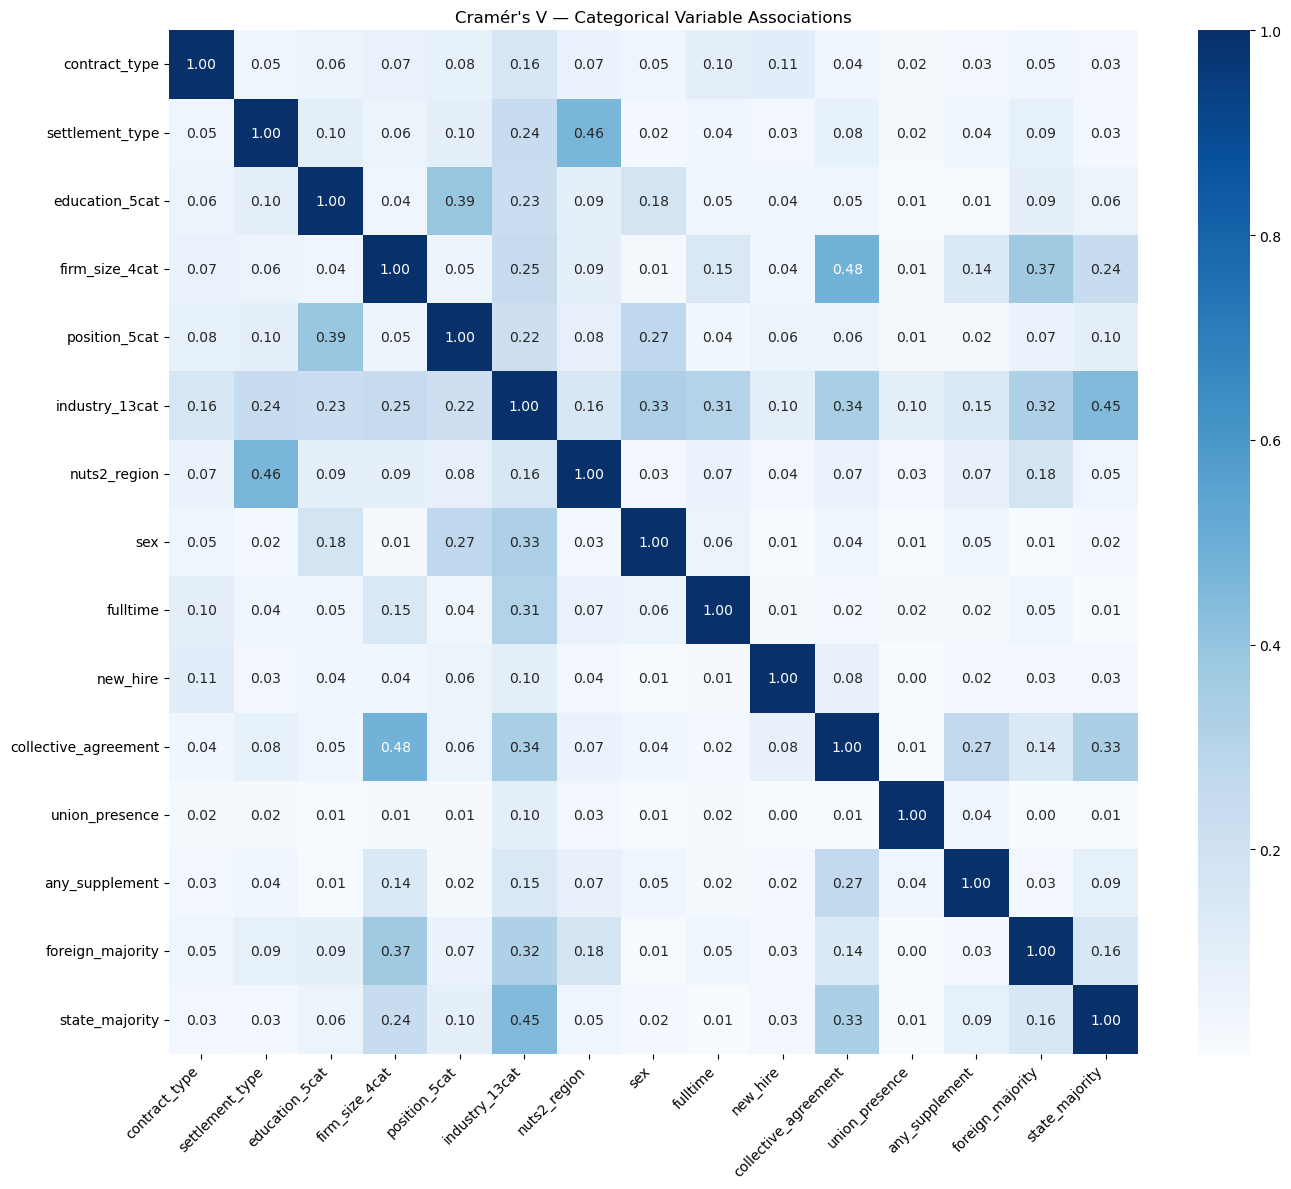

In [8]:
from scipy.stats import chi2_contingency
import itertools

cat_cols = ['contract_type', 'settlement_type', 'education_5cat', 'firm_size_4cat',
            'position_5cat', 'industry_13cat', 'nuts2_region', 'sex', 'fulltime',
            'new_hire', 'collective_agreement', 'union_presence', 'any_supplement',
            'foreign_majority', 'state_majority']

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(r-1, k-1))

# Compute Cramer's V for all pairs
cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for col1, col2 in itertools.combinations(cat_cols, 2):
    v = cramers_v(df[col1].dropna(), df[col2].dropna())
    cramers_matrix.loc[col1, col2] = v
    cramers_matrix.loc[col2, col1] = v

for col in cat_cols:
    cramers_matrix.loc[col, col] = 1.0

# Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(cramers_matrix.astype(float), annot=True, fmt='.2f', cmap='Blues',
            xticklabels=cat_cols, yticklabels=cat_cols)
plt.title("Cramér's V — Categorical Variable Associations")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("../figs/VIF_cramers.png", dpi=300, bbox_inches='tight')
plt.show()

#### Eta-Squared - Categorical × Continuous Associations

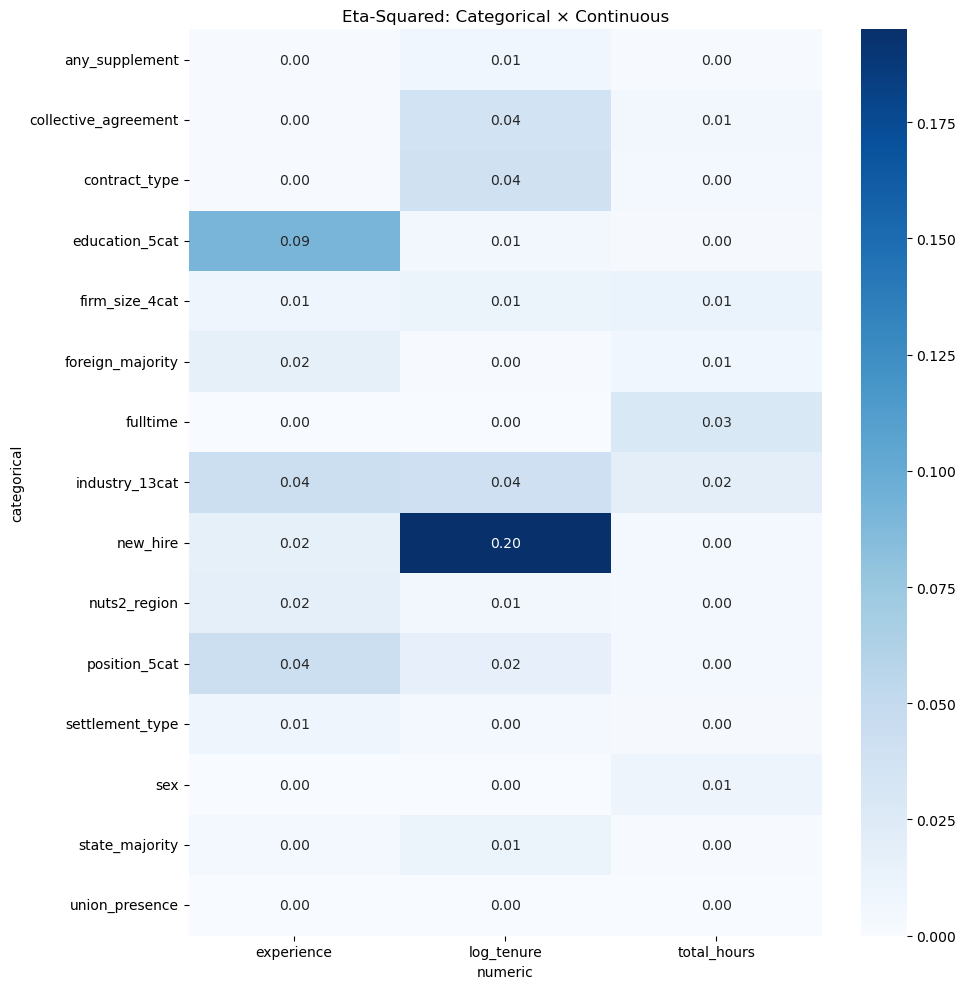

In [9]:
from scipy.stats import f_oneway

cat_cols = ['contract_type', 'settlement_type', 'education_5cat', 'firm_size_4cat',
            'position_5cat', 'industry_13cat', 'nuts2_region', 'sex', 'fulltime',
            'new_hire', 'collective_agreement', 'union_presence', 'any_supplement',
            'foreign_majority', 'state_majority']

numeric_cols = ['experience', 'log_tenure', 'total_hours']

def eta_squared(cat, num):
    groups = [num[cat == c].dropna() for c in cat.dropna().unique()]
    grand_mean = num.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = sum((num - grand_mean)**2)
    return ss_between / ss_total

results = []
for c in cat_cols:
    for n in numeric_cols:
        eta2 = eta_squared(df[c], df[n].dropna())
        results.append({'categorical': c, 'numeric': n, 'eta_squared': round(eta2, 3)})

eta_df = pd.DataFrame(results).pivot(index='categorical', columns='numeric', values='eta_squared')

plt.figure(figsize=(10, 10))
sns.heatmap(eta_df, annot=True, fmt='.2f', cmap='Blues')
plt.title('Eta-Squared: Categorical × Continuous')
plt.tight_layout()
plt.savefig("../figs/VIF_eta_squared.png", dpi=300, bbox_inches='tight')
plt.show()

To assess associations between categorical and continuous predictors, we compute eta-squared (η²), which measures the proportion of variance in a continuous variable explained by the groupings of a categorical variable, the natural analogue of R² for this type of association. The highest values are `new_hire` × `log_tenure` (0.2) and `education_5cat` × `general_experience` (0.09), both of which are economically intuitive rather than indicative of harmful collinearity. All other pairs are below 0.07, confirming that categorical and continuous predictors carry largely independent information.

### Model Specification

We estimate two OLS models. The baseline model includes all main effects without interactions. `union_presence` is excluded from the second model as it was not significant in the baseline (p = 0.99). The interaction model adds ownership × worker characteristic interactions motivated by the EDA, where foreign-majority firms showed visually distinct slopes for experience, tenure, total hours, education, and position.

In [10]:
import statsmodels.formula.api as smf

baseline_formula = """
log_earnings ~ foreign_majority + state_majority
             + experience + experience_sq + log_tenure
             + total_hours + sex + education_5cat + position_5cat
             + contract_type + fulltime + any_supplement
             + firm_size_4cat + collective_agreement + union_presence
             + industry_13cat + settlement_type + nuts2_region
"""

baseline_model = smf.ols(baseline_formula, data=df).fit()
print(baseline_model.summary2())

                           Results: Ordinary least squares
Model:                    OLS                    Adj. R-squared:           0.556      
Dependent Variable:       log_earnings           AIC:                      166731.0988
Date:                     2026-05-13 15:40       BIC:                      167184.9814
No. Observations:         177421                 Log-Likelihood:           -83321.    
Df Model:                 44                     F-statistic:              5046.      
Df Residuals:             177376                 Prob (F-statistic):       0.00       
R-squared:                0.556                  Scale:                    0.14981    
--------------------------------------------------------------------------------------
                                       Coef.  Std.Err.    t     P>|t|   [0.025  0.975]
--------------------------------------------------------------------------------------
Intercept                             11.5560   0.0358 322.9446 0.0000 

**Key coefficients: baseline model:**
- `foreign_majority`: +0.22 (~25% wage premium)
- `state_majority`: +0.02 (~2% premium, modest but significant)
- `sex[male]`: +0.14 (~15% gender gap)
- `education[tertiary]`: +0.56 (~75% premium over no/incomplete primary)
- `position[manual]`: -0.52 relative to top management

In [12]:
interaction_formula = """
log_earnings ~ foreign_majority + state_majority
             + experience + experience_sq + log_tenure
             + total_hours + sex + education_5cat + position_5cat
             + contract_type + fulltime + any_supplement
             + firm_size_4cat + collective_agreement
             + industry_13cat + settlement_type + nuts2_region
             + foreign_majority:experience
             + foreign_majority:total_hours
             + foreign_majority:log_tenure
             + foreign_majority:education_5cat
             + foreign_majority:position_5cat
"""

interaction_model = smf.ols(interaction_formula, data=df).fit()
print(f'R-squared: {interaction_model.rsquared:.4f}')
print(f'Adj. R-squared: {interaction_model.rsquared_adj:.4f}')
print(f'N observations: {int(interaction_model.nobs)}')
print(f'AIC: {interaction_model.aic:.2f}')
print(f'BIC: {interaction_model.bic:.2f}')
print(interaction_model.summary2())

R-squared: 0.5699
Adj. R-squared: 0.5698
N observations: 177421
AIC: 161040.15
BIC: 161594.89
                                    Results: Ordinary least squares
Model:                          OLS                          Adj. R-squared:                 0.570      
Dependent Variable:             log_earnings                 AIC:                            161040.1450
Date:                           2026-05-13 15:46             BIC:                            161594.8905
No. Observations:               177421                       Log-Likelihood:                 -80465.    
Df Model:                       54                           F-statistic:                    4353.      
Df Residuals:                   177366                       Prob (F-statistic):             0.00       
R-squared:                      0.570                        Scale:                          0.14507    
-------------------------------------------------------------------------------------------------------

**Key coefficients - interaction model:**
- `foreign_majority` main effect rises to +0.43, now interpreted as the premium
  for top management specifically (baseline worker)
- `foreign_majority × experience`: +0.001 -> slightly higher returns to experience
  at foreign firms
- `foreign_majority × log_tenure`: +0.017 -> higher tenure premium at foreign firms
- `foreign_majority × education[tertiary]`: +0.30 -> foreign firms disproportionately
  reward tertiary-educated workers; lower education interactions insignificant
- `foreign_majority × position[manual]`: -0.74 -> foreign premium reverses for manual
  workers (net effect: -0.31), concentrated entirely at the top of the job hierarchy

**Observations:**

The `foreign_majority` main effect jumps to +0.43, but this now reflects the premium for the baseline worker (top management, no completed primary education, zero experience/tenure/hours), not the average worker. The substantive results are in
the interactions.

**Position interactions dominate.** The foreign premium is concentrated at the top of the job hierarchy and reverses further down:

| Position       | Net foreign premium         |
|----------------|-----------------------------|
| Top management | +0.43 (base)                |
| Management     | +0.43 - 0.34 = +0.09        |
| Professional   | +0.43 - 0.63 = **-0.20**   |
| Clerical       | +0.43 - 0.66 = **-0.23**   |
| Manual         | +0.43 - 0.74 = **-0.31**   |

Foreign firms pay a substantial premium to top management but pay **less** than domestic private firms to professional, clerical, and manual workers, conditional on observables. This is the central finding of the interaction model.

**Education interactions are weak.** Only the tertiary interaction is significant (coef = +0.30, p = 0.01); all lower education categories are insignificant. Foreign firms disproportionately reward tertiary education, but education is otherwise not a major dimension of heterogeneity in the ownership premium.

**Human capital interactions are positive but modest.** `foreign_majority × log_tenure` (+0.017) and `foreign_majority × experience` (+0.001) are both significant, foreign firms reward tenure and experience somewhat more than domestic firms. `foreign_majority × total_hours` (+0.001) is significant but economically negligible.

**Condition number concern.** The condition number rises sharply from ~82k to ~246k, likely driven by thin cell counts in the `foreign_majority × education` interactions (foreign-majority firms are rare in some education cells). 

The education interaction coefficients should be interpreted cautiously: sparse cells (few foreign-majority observations in lower education categories) inflate standard errors and likely drive the elevated condition number, though this does not affect the position or human capital interactions, nor the substantive conclusions given that those coefficients are insignificant regardless.

In [13]:
print(f'Baseline - AIC: {baseline_model.aic:.0f}, BIC: {baseline_model.bic:.0f}')
print(f'Interaction - AIC: {interaction_model.aic:.0f}, BIC: {interaction_model.bic:.0f}')

Baseline - AIC: 166731, BIC: 167185
Interaction - AIC: 161040, BIC: 161595


Both information criteria favor the interaction model: AIC drops from 166,731 to 161,040 and BIC from 167,185 to 161,595, a reduction of ~5,700 units in both cases. This is decisive by any conventional threshold and confirms that the interaction terms jointly improve fit enough to justify the additional 10 parameters. That said, model selection here is not really the point. The interactions are motivated by the research question, we are not asking whether a parsimonious baseline fits the data, but whether the foreign ownership premium varies systematically across worker characteristics. The AIC/BIC comparison simply confirms that this heterogeneity is real and not overfitting.

### Regularization Methods

We chose not to employ regularization methods in this analysis. Lasso, ridge, and elastic net are designed to minimize out-of-sample prediction error by shrinking coefficients toward zero, a goal that is orthogonal to ours. Our objective is inference on the ownership wage premium and its heterogeneity across worker characteristics, which requires unbiased, interpretable OLS estimates rather than shrinkage estimators optimized for predictive accuracy.

Lasso is particularly ill-suited here: by zeroing out correlated predictors arbitrarily, it would undermine the identification of the ownership coefficients rather than improve it. Industry, region, and position controls are retained on economic grounds, not because they maximize predictive fit. Ridge regression could in principle serve as a robustness check on the elevated condition number in the interaction model. If OLS and ridge estimates are close, that would confirm that collinearity is not materially distorting our estimates. We did not pursue this given that the condition number concern is localized to the `foreign_majority × education` interactions, which are largely insignificant regardless and do not affect the substantive conclusions.